In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision import models
from torchcam.methods import LayerCAM
from torchvision.models import ResNet18_Weights

model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
weights = ResNet18_Weights.IMAGENET1K_V1
model.eval()
categories = weights.meta['categories']
target_layers = [
    ('Första lagret', model.layer1[-1]),
    ('Andra lagret', model.layer2[-1]),
    ('Tredje lagret', model.layer3[-1]),
    ('Fjärde lagret', model.layer4[-1]),
]

def prep_image(img_path):
    img = Image.open(img_path).convert('RGB')
    process = weights.transforms()
    img_tensor = process(img).unsqueeze(0)
    return img_tensor

def tensor_to_image(img_tensor):
    img = img_tensor.squeeze(0).detach().cpu()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img * std + mean
    img = img.clamp(0, 1)
    img = img.permute(1, 2, 0).numpy()
    return img

def get_image_category(img, target_label=None):
    output = model(img)
    probs = torch.softmax(output, dim=1)
    values, indices = probs.topk(5, dim=1)
    img_cat = []
    rank = None
    target_prob = None
    correct = None

    for value, index, prediction in zip(values[0], indices[0], range(1, 6)):
        img_cat.append({
            'prediction': prediction,
            'class name': categories[index.item()],
            'probability': f'{float(value.item())*100:.5f} %'
        })

        if target_label is not None:
            target_idx = categories.index(target_label)
            sorted_indices = probs.argsort(dim=1, descending=True)
            rank = (sorted_indices[0] == target_idx).nonzero(as_tuple=True)[0].item() + 1
            pred_class = categories[indices[0][0].item()]
            correct = pred_class.lower() == target_label.lower()
            target_prob = f'{probs[0][target_idx].item()*100:.5f} %'

    return {
        'top5': img_cat,
        'correct prediction': correct,
        'target rank': rank,
        'target probability': target_prob,
        }

def generate_cam_grid(img_tensor, target_label):
    cam_input = img_tensor.clone().detach()
    img_np = tensor_to_image(img_tensor)
    fig, axes = plt.subplots(3, len(target_layers), figsize=(16, 9))
    for ax in axes[0]:
        ax.imshow(img_np)
        ax.axis('off')

    for i, (name, layer) in enumerate(target_layers):
        cam_extractor = LayerCAM(model, target_layer=layer)
        output = model(cam_input)
        pred_class = output.argmax(dim=1).item()
        class_name = categories[pred_class]

        axes[0][i].set_title('Orginal')
        
        activation_map = cam_extractor(pred_class, output)[0].squeeze().detach().cpu().numpy()
        activation_map = (activation_map - activation_map.min()) / (activation_map.max() - activation_map.min() + 1e-8)
        axes[1, i].imshow(activation_map, cmap='jet')
        axes[1, i].set_title(f'{name} (raw)')
        axes[1, i].axis('off')

        heatmap = Image.fromarray(np.uint8(255 * activation_map))
        heatmap = heatmap.resize((img_np.shape[1], img_np.shape[0]))
        heatmap = np.array(heatmap) / 255.0
        axes[2, i].imshow(img_np)
        axes[2, i].imshow(heatmap, cmap='jet', alpha=0.35)
        axes[2, i].set_title(f'{name} (overlay)')
        axes[2, i].axis('off')

    correct = class_name.lower() == target_label.lower()
    status = '✓' if correct else '✗'
    plt.suptitle(f'Target: {target_label}\nPrediction: {class_name} ({status})',
    fontsize=14)
    plt.tight_layout()
    plt.show()

images = [
    prep_image('skata_P.jpg'),
    prep_image('skata_N.jpg'),
    prep_image('mantis_P.jpg'),
    prep_image('mantis_N.jpg'),
    prep_image('barra_P.jpg'),
    prep_image('barra_N.jpg')
]

targets = [
    'magpie', 'magpie',
    'mantis', 'mantis',
    'barracouta', 'barracouta'
]

results = []

for i, (img, target) in enumerate(zip(images, targets)):
    result = get_image_category(img, target)
    results.append({
        'image': i + 1,
        'target': target,
        'result': result
    })


# 1. Introduktion

Convolutional neural networks (CNN) är en av de mest framgångsrika metoderna inom djupinlärning för bildklassificering. Trots deras höga prestanda är de dock ofta svåra att tolka, vilket gör det viktigt att kunna undersöka hur modellerna faktiskt kommer fram till sina beslut.

Ett sätt att analysera detta är genom feature attribution, där man försöker förstå vilka delar av en indata som påverkar modellens prediktion. I denna uppgift används Class Activation Maps (CAM) för det då CAM visualiserar vilka delar av en bild som bidrar mest till modellens klassificering.

Syftet med denna rapport är att analysera hur en förtränad CNN-modell använder olika bildregioner för att fatta beslut och klassificera en bilds objekt utifrån en katalog med 1000 klasser, samt att undersöka modellens generaliseringsförmåga och begränsningar.

*Rapporten har korrekturlästs av en LLM med små justeringar.*

# 2. Data och Modell

I denna uppgift används modellen ResNet18, förtränad på ImageNet-datasetet som innehåller 1000 olika klasser. Modellen valdes eftersom den är relativt lättviktig men samtidigt tillräckligt kraftfull för att ge meningsfulla resultat.

Datamängden som användes för undersökningen består av sex bilder, två per klass, där en bild har objektet som huvudsakligt fokus (positiv) och den andra saknar detta fokus (negativ).

Tre klasser valdes från ImageNet:  
magpie  
mantis  
barracouta  

I två av de negativa exemplen förekommer objektet indirekt, exempelvis som en del av en logotyp eller i ett annat semantiskt sammanhang. Detta möjliggör analys av hur modellen hanterar fall där relevanta visuella element finns närvarande men inte utgör bildens primära innehåll.

Den tredje negativa bilden innehåller ett objekt som inte finns representerat i ImageNet (gädda), vilket möjliggör analys av modellens beteende utanför träningsdistributionen.

# 3. Metod

För att visualisera vilka delar av bilderna modellen fokuserar på användes LayerCAM.

Till skillnad från standard-CAM applicerades metoden på flera lager:

Tidigt lager (layer1)
Mellanlager (layer2, layer3)
Sent lager (layer4)

Detta möjliggör analys av hur representationen förändras genom nätverket:

Tidiga lager: enkla features (kanter, texturer)
Sena lager: mer semantiska objekt

# 4. Resultat

Modellen presterade generellt väl på de positiva exemplen, men med varierande säkerhet:  
Positiv Magpie: Korrekt klassad med $\approx$ 98% sannolikhet  
Positiv Mantis: Korrekt klassad med $\approx$ 78% sannolikhet  
Positiv Barracouta: Korrekt klassad med $\approx$ 88% sannolikhet  

För negativa exempel observerades:  
Negativ Magpie: Klassades som revolver med $\approx$ 19% sannolikhet, magpie var rankad 398 bland logits med $\approx$ 0,004% sannolikhet  
Negativ Mantis: Klassades som bulletproof vest med ungefär 15% sannolikhet, mantis var rankad 786 bland logits med ungefär 0,0003% sannolikhet  
Negativ Barracouta: Klassades felaktigt som barracouta med ungefär 83% sannolikhet, detta analyseras vidare i diskussionen  

# 5. Diskussion

Den första bilden som analyserades var ett positivt exempel för klassen *magpie*. Bilden utgör ett tydligt och representativt exempel av objektet, vilket även återspeglas i modellens prediktion. Klassen identifierades korrekt med hög sannolikhet (cirka 98%), och övriga topp 5-prediktioner utgjordes av andra fågelarter med betydligt lägre sannolikheter (under 1%).

Vid analys av LayerCAM-visualiseringarna observeras en tydlig progression mellan lagren. I det första lagret är aktiveringarna främst koncentrerade till enkla visuella egenskaper såsom konturer och kontraster, exempelvis skillnader mellan fjäderdräktens ljusa och mörka partier. 

I det andra lagret förstärks dessa strukturer ytterligare, samtidigt som mer distinkta detaljer, såsom ögat, börjar framträda. I det tredje lagret breddas aktiveringen och täcker större delar av objektet, vilket indikerar att mer komplexa mönster har identifierats. 

I det fjärde lagret är aktiveringen tydligt koncentrerad till hela fågeln, vilket tyder på att modellen har bildat en mer semantisk representation av objektet.

Detta beteende är i linje med hur konvolutionella neurala nätverk är uppbyggda, där tidiga lager extraherar lågnivåfeatures såsom kanter och texturer, medan senare lager representerar mer abstrakta och semantiskt meningsfulla strukturer.

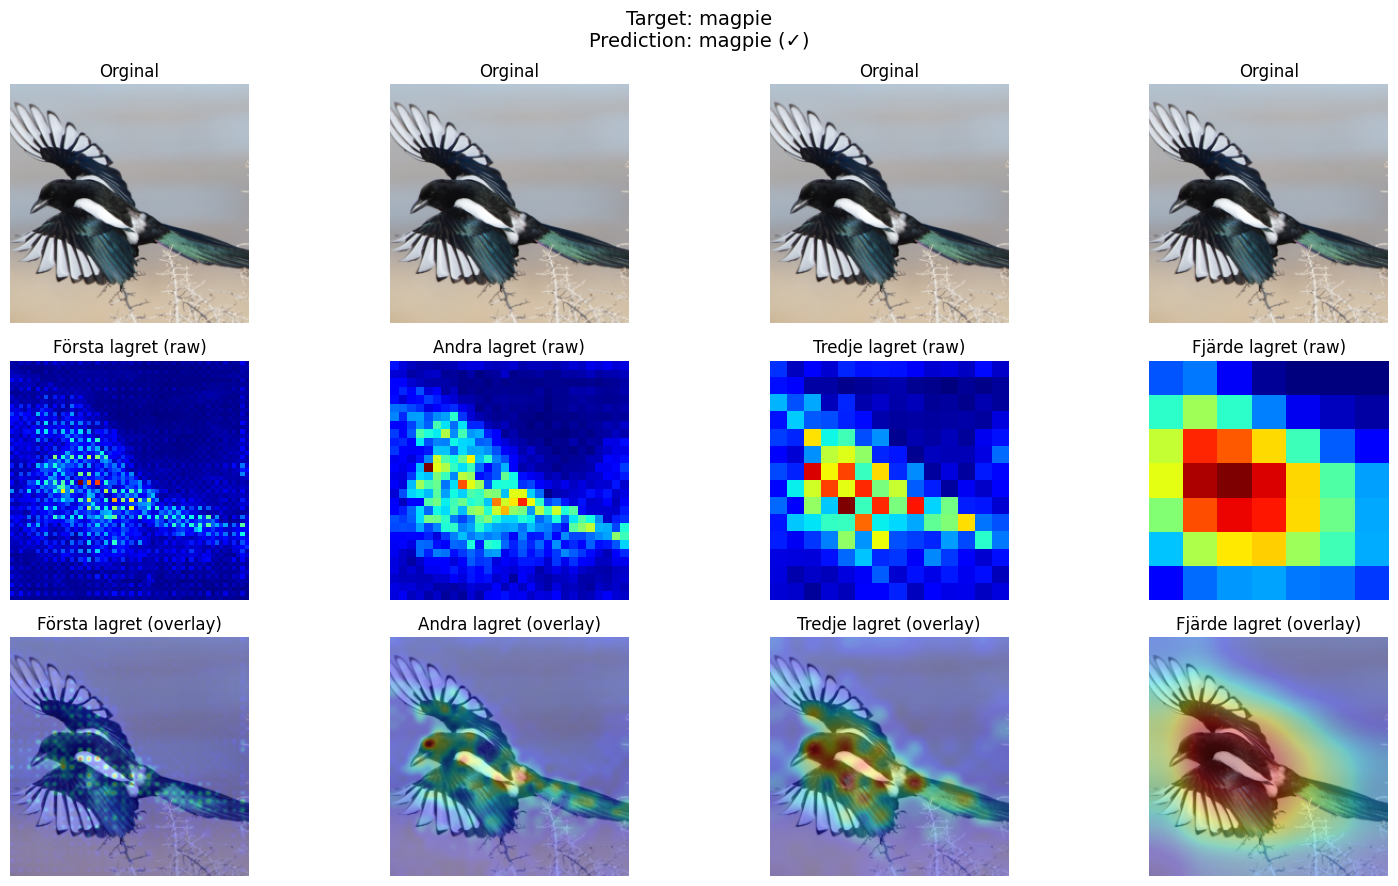

{'image': 1,
 'target': 'magpie',
 'result': {'top5': [{'prediction': 1,
    'class name': 'magpie',
    'probability': '97.88718 %'},
   {'prediction': 2, 'class name': 'jay', 'probability': '0.71598 %'},
   {'prediction': 3, 'class name': 'peacock', 'probability': '0.50866 %'},
   {'prediction': 4, 'class name': 'black grouse', 'probability': '0.28943 %'},
   {'prediction': 5, 'class name': 'hornbill', 'probability': '0.17729 %'}],
  'correct prediction': True,
  'target rank': 1,
  'target probability': '97.88718 %'}}

In [107]:
generate_cam_grid(images[0], targets[0])
results[0]

Den andra bilden utgjorde ett negativt exempel för klassen *magpie*. Bilden föreställer en discgolfspelare i färd med att kasta en disc. Modellen klassificerade bilden som *revolver* med relativt låg sannolikhet (cirka 19%), och övriga topp 5-prediktioner utgjordes av objekt kopplade till fysiska aktiviteter eller handhållna föremål.

Vid analys av LayerCAM-visualiseringarna observeras en liknande progression mellan lagren som i det positiva exemplet, men med en tydlig skillnad i vad modellen fokuserar på. Istället för att koncentrera sig på specifika objekt, riktas aktiveringarna främst mot kontextuella element i bilden, såsom spelarens kropp och hållning.

I de senare lagren kan det observeras att modellen delvis identifierar logotypen på spelarens rygg, vilken tydligt föreställer en skata. Denna aktivering är dock svag och får begränsad påverkan på den slutliga prediktionen. 

Detta tyder på att modellen i högre grad påverkas av kontext än av mindre, men semantiskt relevanta, objekt i bilden. Fenomenet kan beskrivas som *context dominance over object relevance*, där globala bilddrag väger tyngre än lokala detaljer.

Som följd av detta rankas klassen *magpie* mycket lågt (plats 398) med en sannolikhet på cirka 0,004%, trots att relevanta visuella signaler faktiskt finns närvarande i bilden.

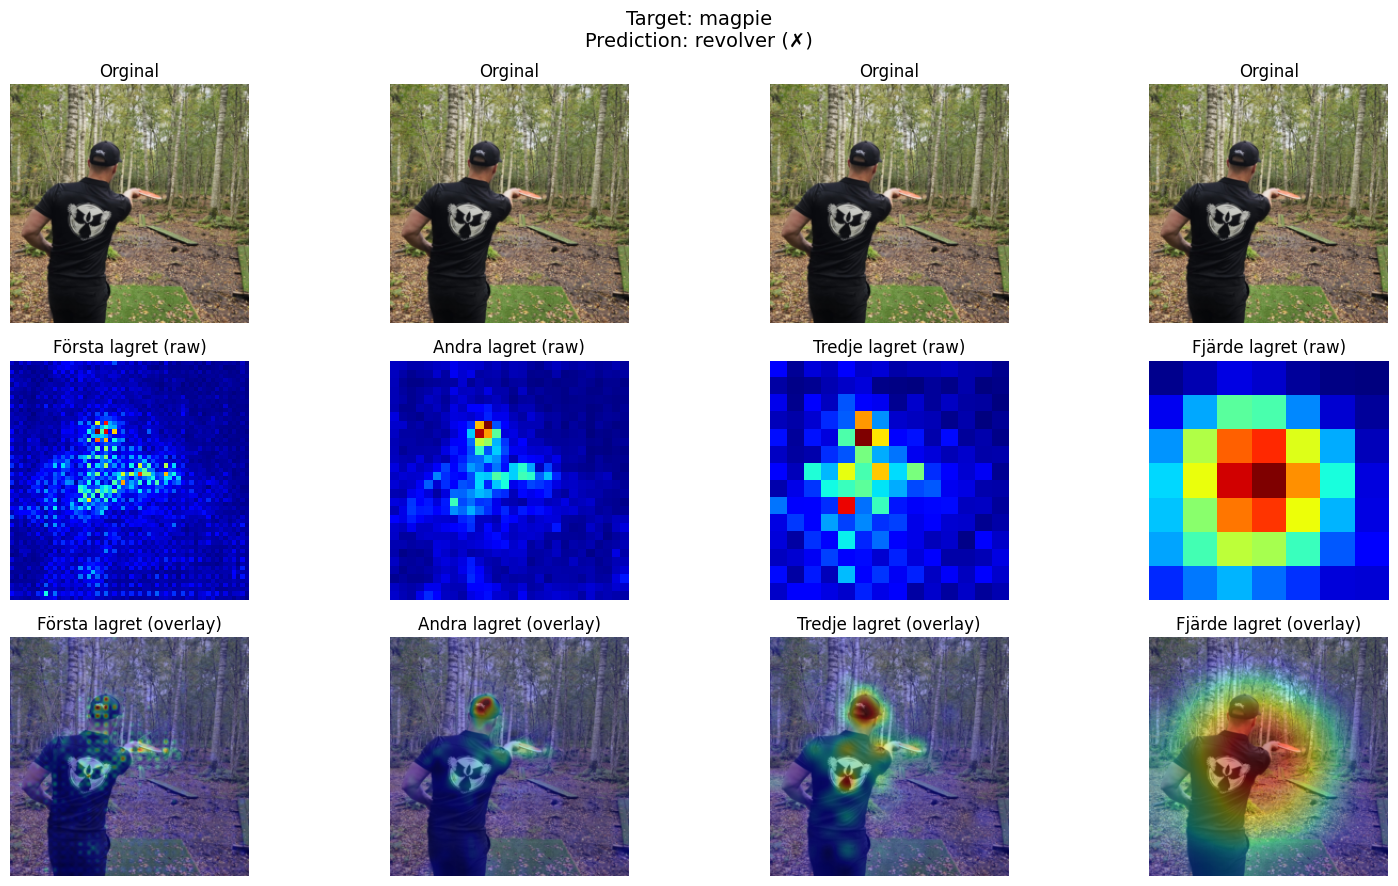

{'image': 2,
 'target': 'magpie',
 'result': {'top5': [{'prediction': 1,
    'class name': 'revolver',
    'probability': '18.83963 %'},
   {'prediction': 2, 'class name': 'ski mask', 'probability': '13.70807 %'},
   {'prediction': 3, 'class name': 'bow', 'probability': '9.38601 %'},
   {'prediction': 4, 'class name': 'rifle', 'probability': '7.62088 %'},
   {'prediction': 5,
    'class name': 'punching bag',
    'probability': '5.81198 %'}],
  'correct prediction': False,
  'target rank': 398,
  'target probability': '0.00386 %'}}

In [108]:
generate_cam_grid(images[1], targets[1])
results[1]

Den tredje bilden var ett positivt exempel för klassen *mantis*, där en bönsyrsa upptar större delen av bildytan. Modellen klassificerade bilden korrekt med en sannolikhet på cirka 78%, vilket är lägre än för *magpie*, men fortfarande indikerar en relativt hög säkerhet.

En möjlig förklaring till den lägre säkerheten är att vissa visuella egenskaper hos objektet överlappar mer med andra klasser. Detta illustreras av att klasserna *dragonfly* och *walking stick* förekommer bland topprediktionerna, båda på circa 4%. 

Vid analys av LayerCAM-visualiseringarna observeras att vissa aktiveringar i de senare lagren sammanfaller med bönsyrsans främre ben, vilka visuellt kan likna formen hos en vandrande pinne, samt stort fokus på bönsyrsans huvud som liknar en trollsländas. Detta tyder på att modellen delvis baserar sin prediktion på formmässiga likheter snarare än enbart objektets helhetsrepresentation.

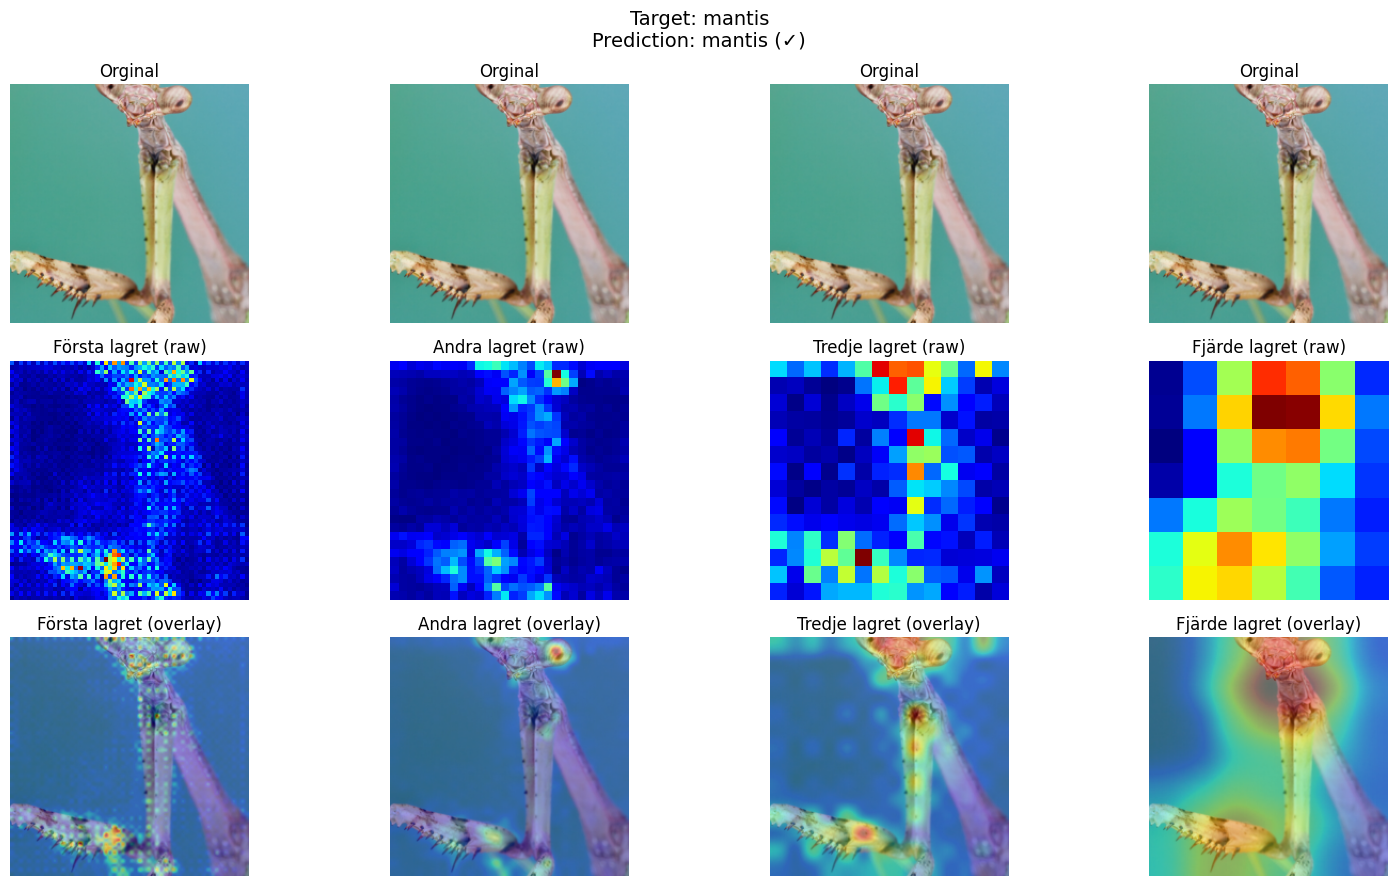

{'image': 3,
 'target': 'mantis',
 'result': {'top5': [{'prediction': 1,
    'class name': 'mantis',
    'probability': '78.27528 %'},
   {'prediction': 2, 'class name': 'dragonfly', 'probability': '4.38686 %'},
   {'prediction': 3,
    'class name': 'walking stick',
    'probability': '3.95052 %'},
   {'prediction': 4, 'class name': 'banded gecko', 'probability': '1.83338 %'},
   {'prediction': 5, 'class name': 'lacewing', 'probability': '1.46688 %'}],
  'correct prediction': True,
  'target rank': 1,
  'target probability': '78.27528 %'}}

In [113]:
generate_cam_grid(images[2], targets[2])
results[2]

Bild 4 utgjorde ett negativt exempel för klassen mantis och föreställer en kung fu-utövare i en posering inspirerad av bönsyrse-stilen. Modellen klassificerade bilden som *bulletproof vest* med en sannolikhet på cirka 15%.

Varken kung fu eller martial arts utgör egna klasser i ImageNet, och den närmast relaterade klassen *boxer* återfinns först på plats 261 med en sannolikhet på cirka 0,02% . Detta indikerar att modellen inte primärt tolkar scenens semantiska innehåll (kampsport), utan istället fokuserar på mer konkreta visuella attribut. Det skulle dock kunna vara hundrasen *boxer* som klassen refererar till och inte en boxare och därmed vara helt irrelevant.

Analys av topp-5-prediktionerna visar att flera av dessa relaterar till klädsel, vilket tyder på att modellens beslut i hög grad drivs av object-level features såsom textur, form och färg hos kläderna. Samtidigt förekommer även klasser kopplade till fysisk aktivitet, vilket antyder att kroppens posering fortfarande påverkar prediktionen, om än i mindre utsträckning.

Detta illustrerar hur modellen i detta fallet prioriterar tydliga visuella objekt framför mer abstrakta eller kontextuella tolkningar av en scen, till skillnad från det negativa exemplet för *magpie*.

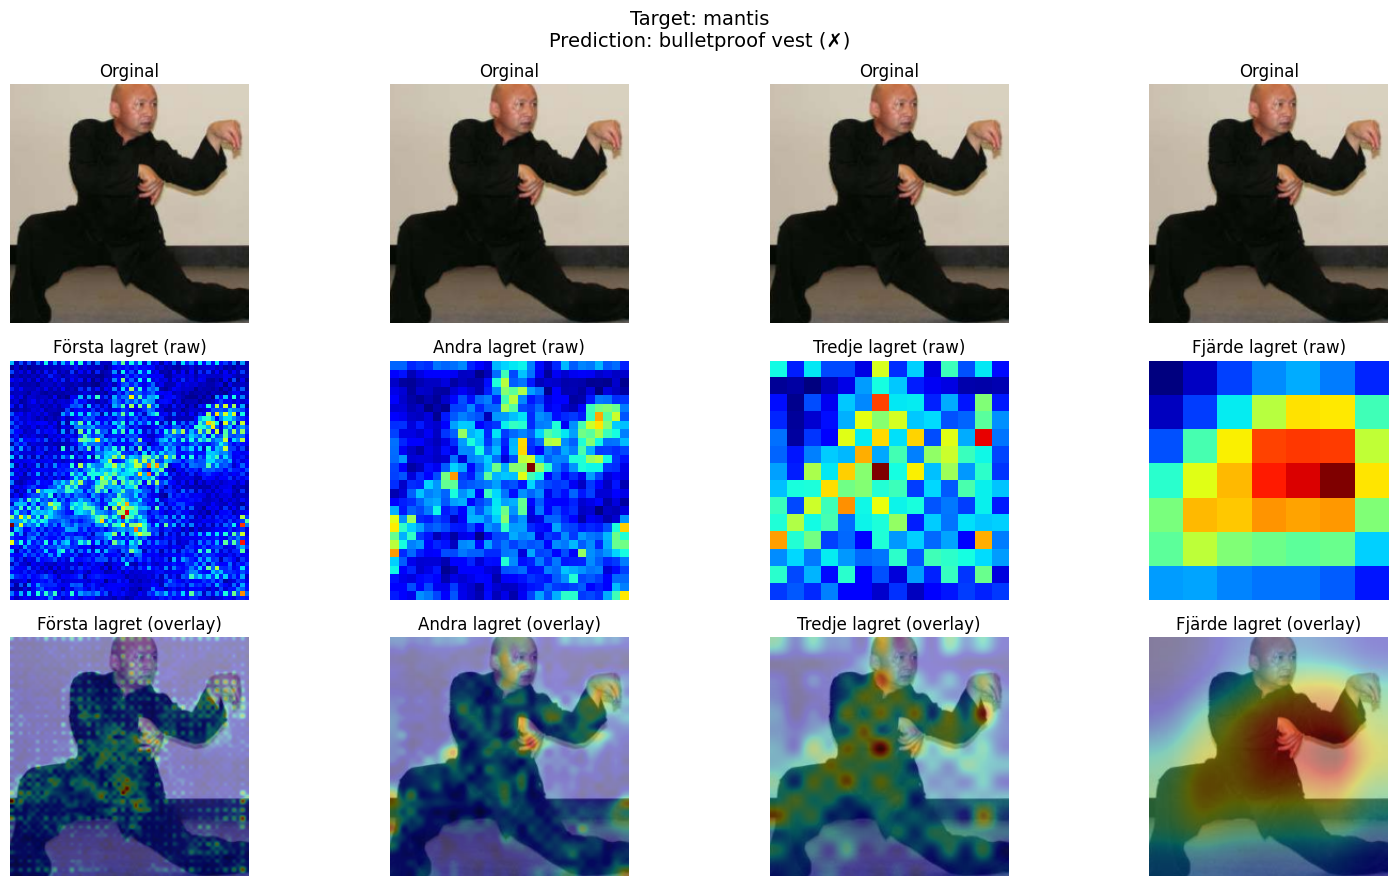

{'image': 4,
 'target': 'mantis',
 'result': {'top5': [{'prediction': 1,
    'class name': 'bulletproof vest',
    'probability': '15.18846 %'},
   {'prediction': 2, 'class name': 'dumbbell', 'probability': '14.59979 %'},
   {'prediction': 3, 'class name': 'punching bag', 'probability': '8.51610 %'},
   {'prediction': 4, 'class name': 'suit', 'probability': '8.24224 %'},
   {'prediction': 5, 'class name': 'Loafer', 'probability': '5.53800 %'}],
  'correct prediction': False,
  'target rank': 786,
  'target probability': '0.00028 %'}}

In [ ]:
generate_cam_grid(images[3], targets[3])
results[3]

Bild 5 utgjorde ett positivt exempel för klassen *barracouta*. Bilden föreställer en fisk med tydligt avlång kropp och distinkta fenstrukturer. Modellen klassificerade bilden korrekt med en sannolikhet på cirka 88%.

De övriga klasserna i topp-5 utgörs uteslutande av andra fiskarter, såsom *gar*, *sturgeon*, *coho* och *tench*. Detta indikerar att modellen inte bara identifierar objektet som en fisk, utan även särskiljer mellan olika typer av fiskar baserat på finare visuella egenskaper.

Att klasser som gar och sturgeon rankas högt är särskilt intressant då dessa delar flera morfologiska drag med barracouta, exempelvis en långsträckt kropp och liknande proportioner. Detta tyder på att modellen i hög grad baserar sin klassificering på form- och strukturrelaterade features snarare än enbart generella kategorier.

LayerCAM-visualiseringarna visar att aktiveringen koncentreras kring fiskens kropp, särskilt längs dess konturer och med särskild fokus på dess huvudparti. I de tidiga lagren framträder främst enkla strukturer såsom kanter och silhuett, medan de senare lagren fokuserar på mer semantiskt relevanta delar av objektet.

Sammantaget visar detta exempel att modellen uppvisar god förmåga att särskilja mellan visuellt liknande klasser, samtidigt som dess felmarginaler begränsas till biologiskt närbesläktade arter.

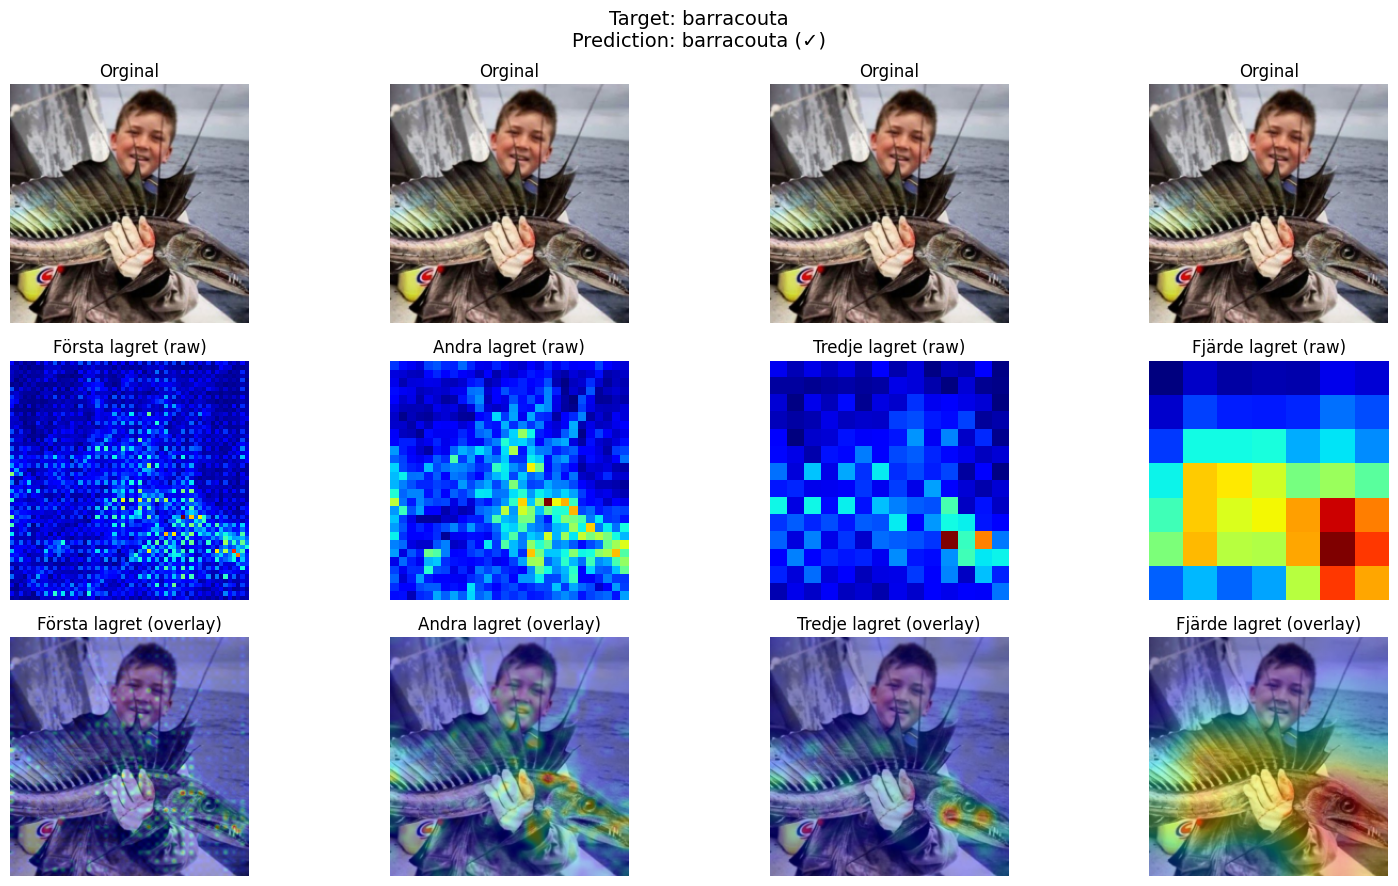

{'image': 5,
 'target': 'barracouta',
 'result': {'top5': [{'prediction': 1,
    'class name': 'barracouta',
    'probability': '88.24455 %'},
   {'prediction': 2, 'class name': 'gar', 'probability': '6.81722 %'},
   {'prediction': 3, 'class name': 'sturgeon', 'probability': '4.01340 %'},
   {'prediction': 4, 'class name': 'coho', 'probability': '0.69258 %'},
   {'prediction': 5, 'class name': 'tench', 'probability': '0.20501 %'}],
  'correct prediction': True,
  'target rank': 1,
  'target probability': '88.24455 %'}}

In [124]:
generate_cam_grid(images[4], targets[4])
results[4]

Slutligen bild 6 utgjorde ett negativt exempel för klassen *barracouta* och föreställer en gädda, en art som inte finns representerad i ImageNet-datasetet. Trots detta klassificerade modellen bilden som *barracouta* med en hög sannolikhet på cirka 83%.

Vid första anblick framstår detta som en felklassificering, men analysen visar att modellen istället gör en rimlig approximation inom den begränsade klassuppsättning den har tillgång till. Gäddan delar flera visuella egenskaper med *barracouta*, såsom en långsträckt kropp, spetsigt huvud och liknande proportioner.

Topp-5-prediktionerna består uteslutande av fiskarter, vilket indikerar att modellen korrekt identifierar den övergripande kategorin, men saknar möjlighet att särskilja arten då korrekt klass inte finns representerad. Detta är ett tydligt exempel på hur modellen generaliserar inom sin träningsdistribution men samtidigt är begränsad av dess klassrum.

LayerCAM-visualiseringarna visar att modellen fokuserar på fiskens kropp och huvud, vilket överensstämmer med de features som används för att särskilja mellan olika fiskarter. Detta stärker tolkningen att klassificeringen baseras på relevanta visuella attribut snarare än slumpmässiga mönster.

Exemplet illustrerar en central begränsning hos klassificeringsmodeller tränade på fasta kategorier: när ett objekt inte finns representerat i träningsdatan kommer modellen att projicera det på den mest liknande kända klassen, även om detta leder till en tekniskt felaktig men semantiskt rimlig prediktion.

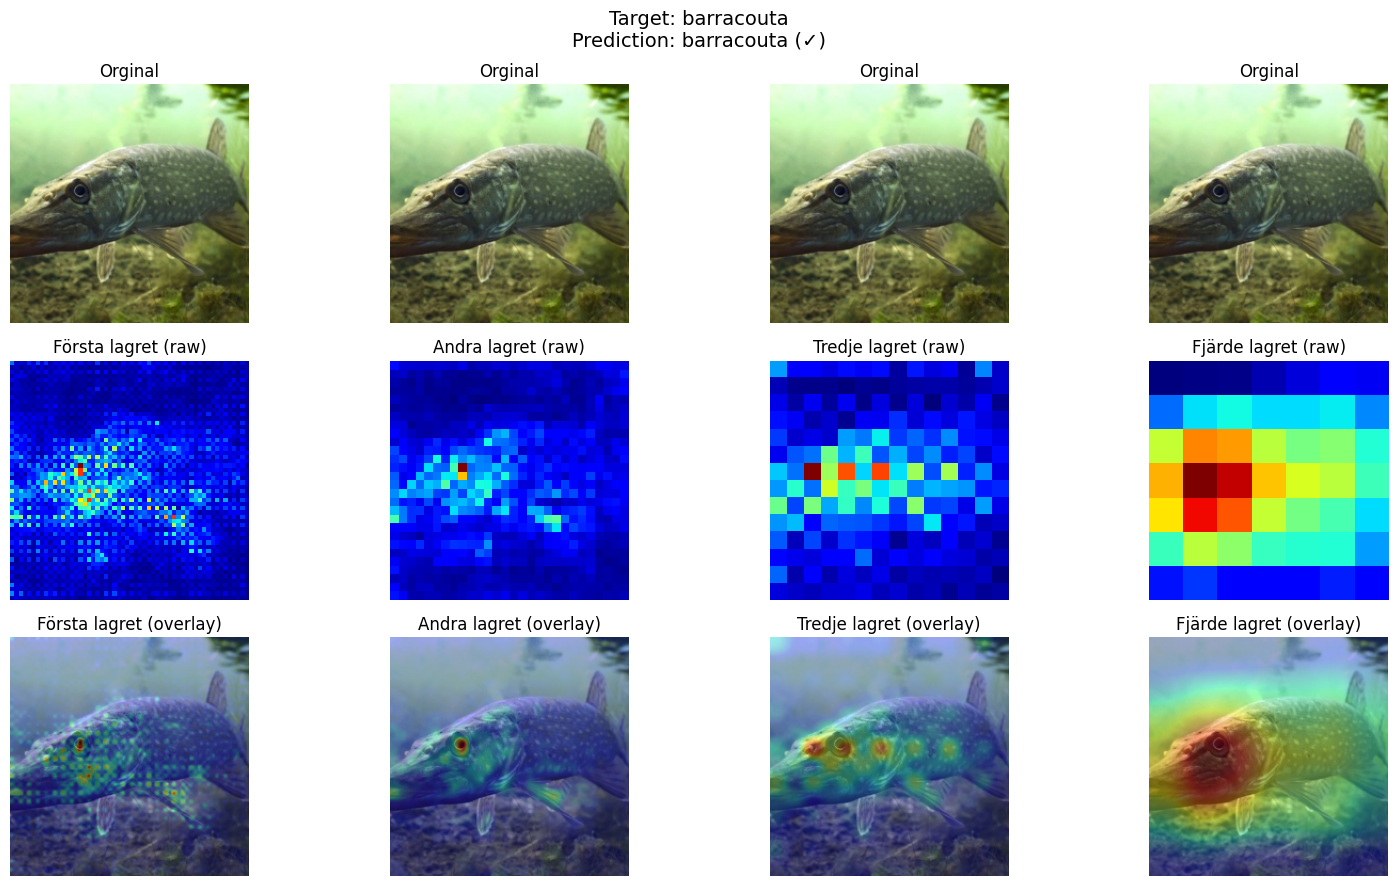

{'image': 6,
 'target': 'barracouta',
 'result': {'top5': [{'prediction': 1,
    'class name': 'barracouta',
    'probability': '82.55106 %'},
   {'prediction': 2, 'class name': 'gar', 'probability': '11.24641 %'},
   {'prediction': 3, 'class name': 'tench', 'probability': '2.43659 %'},
   {'prediction': 4, 'class name': 'sturgeon', 'probability': '1.98895 %'},
   {'prediction': 5, 'class name': 'eel', 'probability': '1.37449 %'}],
  'correct prediction': True,
  'target rank': 1,
  'target probability': '82.55106 %'}}

In [125]:
generate_cam_grid(images[5], targets[5])
results[5]

In [121]:
get_image_category(images[3], 'boxer')


{'top5': [{'prediction': 1,
   'class name': 'bulletproof vest',
   'probability': '15.18846 %'},
  {'prediction': 2, 'class name': 'dumbbell', 'probability': '14.59979 %'},
  {'prediction': 3, 'class name': 'punching bag', 'probability': '8.51610 %'},
  {'prediction': 4, 'class name': 'suit', 'probability': '8.24224 %'},
  {'prediction': 5, 'class name': 'Loafer', 'probability': '5.53800 %'}],
 'correct prediction': False,
 'target rank': 261,
 'target probability': '0.01738 %'}